<a href="https://colab.research.google.com/github/rikaahire/cfpb-admin-effects/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

credit_reporting_variants = [
    'Credit reporting',
    'Credit reporting or other personal consumer reports',
    'Credit reporting, credit repair services, or other personal consumer reports'
]

payday_variants = [
    'Payday loan',
    'Payday loan, title loan, or personal loan',
    'Payday loan, title loan, personal loan, or advance loan'
]

bank_variants = [
    'Bank account or service',
    'Checking or savings account'
]

credit_card_variants = [
    'Credit card',
    'Credit card or prepaid card',
    'Prepaid card'
]

money_transfer_variants = [
    'Money transfers',
    'Virtual currency',
    'Money transfer, virtual currency, or money service'
]

company_response_variants = [
    'Closed',
    'Closed with explanation'
]

referral_variants = [
    'Referral',
    'Web Referral'
]

manual_variants = [
    'Email',
    'Fax',
    'Postal mail'
]

needed_cols = [
    'Date received',
    'Date sent to company',
    'Product',
    'Submitted via',
    'Company response to consumer',
    'Timely response?',
    'ZIP code'
]

start_date = pd.to_datetime('2021-01-20')

print("Processing in chunks to save RAM...")

chunks = []
for chunk in pd.read_csv(url,
                         compression='zip',
                         usecols=needed_cols,
                         chunksize=100000,
                         low_memory=False):
    chunk['Product'] = chunk['Product'].replace(credit_reporting_variants, 'Credit Reporting')
    chunk['Product'] = chunk['Product'].replace(payday_variants, 'Payday Loan')
    chunk['Product'] = chunk['Product'].replace(bank_variants, 'Bank Account or Service')
    chunk['Product'] = chunk['Product'].replace(credit_card_variants, 'Credit Card or Prepaid Card')
    chunk['Product'] = chunk['Product'].replace(money_transfer_variants, 'Money Transfer, Virtual Currency, or Money Service')
    chunk['Company response to consumer'] = chunk['Company response to consumer'].replace(company_response_variants, 'Closed with Explanation')
    chunk['Submitted via'] = chunk['Submitted via'].replace(manual_variants, 'Email, Fax, or Postal Mail')
    chunk['Submitted via'] = chunk['Submitted via'].replace(referral_variants, 'Referral')
    chunk['Date received'] = pd.to_datetime(chunk['Date received'])
    filtered_chunk = chunk[chunk['Date received'] >= start_date]

    chunks.append(filtered_chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Success! Dataframe loaded with {len(df):,} rows.")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")

df.head()

Processing in chunks to save RAM...
Success! Dataframe loaded with 13,058,078 rows.
Date range: 2021-01-20 to 2026-05-06


,Date received,Product,ZIP code,Submitted via,Date sent to company,Company response to consumer,Timely response?
0,2024-01-05,Credit Reporting,60502,Web,2024-01-05,Closed with non-monetary relief,Yes
1,2024-01-21,Credit Reporting,27401,Web,2024-01-21,Closed with Explanation,Yes
2,2024-01-23,Credit Reporting,46222,Web,2024-01-23,Closed with Explanation,Yes
3,2024-01-29,Credit Reporting,60411,Web,2024-01-29,Closed with non-monetary relief,Yes
4,2024-01-08,Credit Reporting,19032,Web,2024-01-08,Closed with non-monetary relief,Yes


In [2]:
df.shape

(13058078, 7)

In [3]:
new_names = {'Date received': 'date_received', 'Product': 'product', 'Submitted via':'submitted_via', 'Date sent to company':'date_sent_to_company', 'Company response to consumer':'company_response_to_consumer', 'Timely response?':'timely_response', 'ZIP code':'zip_code'}
df = df.rename(columns=new_names)
df = df[df['company_response_to_consumer'] != 'In progress']
categorical_cols = ['product', 'submitted_via', 'company_response_to_consumer', 'timely_response', 'zip_code']
df = df[~df['zip_code'].astype(str).str.contains('X')]
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [4]:
fraction_similar = (((df['date_received'] == df['date_sent_to_company']).sum())/df.shape[0])
print(f"Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: {fraction_similar:.2%}")

Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: 96.29%


In [5]:
!pip install census us
from census import Census
from us import states

# Replace with your actual key
c = Census("1e55abc84d703c5a4403570935082050f58fb16a")

# Fetch specific variables for all ZCTAs (ZIP Codes)
# B19013_001E = Median Household Income
# B01003_001E = Total Population
# B15003_022E = Bachelor's Degree
# B03002_003E = % White (non-Hispanic)
# B03002_012E = % Hispanic or Latino
# B01002_001E = Median Age

variables = (
    'NAME',
    'B19013_001E', # Median Income
    'B01003_001E', # Total Pop
    'B15003_022E', # Bachelor's Degree
    'B03002_003E', # White
    'B03002_012E', # Hispanic
    'B02001_003E', # Black
    'B01002_001E',  # Median Age
    'B23025_003E', # Civilian Labor Force
    'B23025_005E', # Unemployed Count
    'B25003_001E', # Total Housing Units
    'B25003_002E'  # Owner Occupied Units
)

data = c.acs5.get(variables, {'for': 'zip code tabulation area:*'})

# Convert to DataFrame
census_df = pd.DataFrame(data)
census_df.rename(columns={
    'B19013_001E': 'median_income',
    'B01003_001E': 'total_population',
    'B15003_022E': 'bachelor_degree',
    'B03002_003E': 'white',
    'B03002_012E': 'hispanic_or_latino',
    'B02001_003E': 'black',
    'B01002_001E': 'median_age',
    'B23025_003E': 'labor_force',
    'B23025_005E': 'unemployed_count',
    'B25003_001E': 'total_units',
    'B25003_002E': 'owner_occupied',
    'zip code tabulation area': 'zip_code'
}, inplace=True)
# 4. Calculate all percentages
# Adding epsilon 1e-6 to avoid division by zero
pop = census_df['total_population'] + 1e-6

census_df['percent_black'] = census_df['black'] / pop
census_df['percent_hispanic'] = census_df['hispanic_or_latino'] / pop
census_df['percent_white'] = census_df['white'] / pop
census_df['percent_bachelors'] = census_df['bachelor_degree'] / pop

census_df['percent_unemployed'] = census_df['unemployed_count'] / (census_df['labor_force'] + 1e-6)
census_df['homeownership_rate'] = census_df['owner_occupied'] / (census_df['total_units'] + 1e-6)

# 5. Final Selection
census_df = census_df[[
    'zip_code', 'median_income', 'total_population',
    'median_age', 'percent_white', 'percent_black',
    'percent_hispanic', 'percent_bachelors', 'percent_unemployed', 'homeownership_rate'
]]

census_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.5 MB/s eta 0:00:00


,zip_code,median_income,total_population,median_age,percent_white,percent_black,percent_hispanic,percent_bachelors,percent_unemployed,homeownership_rate
0,00601,19454.0,16669.0,45.3,0.003899,0.014458,0.993101,0.107265,0.205479,0.674584
1,00602,21420.0,37233.0,46.6,0.015470,0.018022,0.972390,0.141058,0.051337,0.735603
2,00603,20933.0,48448.0,46.1,0.010940,0.033273,0.984334,0.138375,0.153543,0.572798
3,00606,20992.0,5163.0,47.9,0.000968,0.001356,0.996707,0.071083,0.000000,0.795161
4,00610,24496.0,25357.0,45.7,0.015420,0.018930,0.964428,0.127144,0.060410,0.716264


In [6]:
missing_values = df.isnull().sum()

missing_values_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
zip_code,2498,0.021597
company_response_to_consumer,17,0.000147
date_received,0,0.000000
product,0,0.000000
submitted_via,0,0.000000
date_sent_to_company,0,0.000000
timely_response,0,0.000000


In [7]:
df.dropna(inplace=True)
df.head()

,date_received,product,zip_code,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response
0,2024-01-05,Credit Reporting,60502,Web,2024-01-05,Closed with non-monetary relief,Yes
1,2024-01-21,Credit Reporting,27401,Web,2024-01-21,Closed with Explanation,Yes
2,2024-01-23,Credit Reporting,46222,Web,2024-01-23,Closed with Explanation,Yes
3,2024-01-29,Credit Reporting,60411,Web,2024-01-29,Closed with non-monetary relief,Yes
4,2024-01-08,Credit Reporting,19032,Web,2024-01-08,Closed with non-monetary relief,Yes


In [8]:
missing_values = census_df.isnull().sum()

missing_values_percentage = (missing_values / len(census_df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
zip_code,0,0.0
median_income,0,0.0
total_population,0,0.0
median_age,0,0.0
percent_white,0,0.0
percent_black,0,0.0
percent_hispanic,0,0.0
percent_bachelors,0,0.0
percent_unemployed,0,0.0
homeownership_rate,0,0.0


In [9]:
# https://cfpb.github.io/api/ccdb/fields.html
df.drop('date_sent_to_company', axis = 1, inplace = True)
df['date_received'] = pd.to_datetime(df['date_received'])
df.head()

,date_received,product,zip_code,submitted_via,company_response_to_consumer,timely_response
0,2024-01-05,Credit Reporting,60502,Web,Closed with non-monetary relief,Yes
1,2024-01-21,Credit Reporting,27401,Web,Closed with Explanation,Yes
2,2024-01-23,Credit Reporting,46222,Web,Closed with Explanation,Yes
3,2024-01-29,Credit Reporting,60411,Web,Closed with non-monetary relief,Yes
4,2024-01-08,Credit Reporting,19032,Web,Closed with non-monetary relief,Yes


In [10]:
bins = [
    pd.Timestamp('2021-01-20'),
    pd.Timestamp('2025-01-20'),
    pd.Timestamp('2029-01-20')
]

labels = ['Biden', 'Trump_Two']

df['president_date_received'] = pd.cut(df['date_received'], bins=bins, labels=labels, right=False, ordered=False)
df.drop('date_received', axis = 1, inplace = True)

To prevent identifying individuals in sparsely populated areas, the CFPB only publishes the ZIP code if the Census Tabulation Area associated with it has at least 20,000 residents.

If you live in a small town or a rural area with fewer than 20,000 people, the database automatically masks your ZIP code as "XXXXX" to ensure your complaint can't be traced back to your household.

In [11]:
# Ensure zip codes are strings and formatted the same way (5 digits)
census_df['zip_code'] = census_df['zip_code'].astype(str).str.zfill(5)
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)

# Merge with your complaints data
# 'left' join preserves all complaints even if a zip isn't in the census file
df = df.merge(census_df, on='zip_code', how='inner')
df.drop(['zip_code'], axis = 1, inplace = True)
df.head()

,product,submitted_via,company_response_to_consumer,timely_response,president_date_received,median_income,total_population,median_age,percent_white,percent_black,percent_hispanic,percent_bachelors,percent_unemployed,homeownership_rate
0,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden,156904.0,23308.0,39.1,0.472971,0.076369,0.110005,0.246182,0.047394,0.785739
1,Credit Reporting,Web,Closed with Explanation,Yes,Biden,47972.0,21920.0,29.0,0.266560,0.607117,0.073723,0.110219,0.066339,0.364471
2,Credit Reporting,Web,Closed with Explanation,Yes,Biden,50783.0,38887.0,31.4,0.295317,0.267107,0.373672,0.072801,0.090162,0.482769
3,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden,62073.0,52175.0,35.5,0.194633,0.496119,0.257614,0.094279,0.116404,0.652333
4,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden,61306.0,6772.0,30.5,0.379652,0.480360,0.071766,0.078411,0.103202,0.676150


In [12]:
df.shape

(11491555, 14)

In [13]:
df['president_date_received'].value_counts()

,count
president_date_received,
Trump_Two,6482146
Biden,5009409


In [14]:
df['product'].value_counts()

,count
product,
Credit Reporting,9963861
Debt collection,648377
Credit Card or Prepaid Card,279023
Bank Account or Service,228109
"Money Transfer, Virtual Currency, or Money Service",117035
Mortgage,101568
Vehicle loan or lease,57981
Student loan,53148
Payday Loan,35812


In [15]:
df['submitted_via'].value_counts()

,count
submitted_via,
Web,11296891
Phone,100658
Referral,65007
"Email, Fax, or Postal Mail",28999


In [16]:
df['company_response_to_consumer'].value_counts()

,count
company_response_to_consumer,
Closed with Explanation,6760031
Closed with non-monetary relief,4624951
Closed with monetary relief,89333
Untimely response,17240


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11491555 entries, 0 to 11491554
Data columns (total 14 columns):
 #   Column                        Dtype   
---  ------                        -----   
 0   product                       category
 1   submitted_via                 category
 2   company_response_to_consumer  category
 3   timely_response               category
 4   president_date_received       category
 5   median_income                 float64 
 6   total_population              float64 
 7   median_age                    float64 
 8   percent_white                 float64 
 9   percent_black                 float64 
 10  percent_hispanic              float64 
 11  percent_bachelors             float64 
 12  percent_unemployed            float64 
 13  homeownership_rate            float64 
dtypes: category(5), float64(9)
memory usage: 843.9 MB


In [18]:
df.describe(include='all')

,product,submitted_via,company_response_to_consumer,timely_response,president_date_received,median_income,total_population,median_age,percent_white,percent_black,percent_hispanic,percent_bachelors,percent_unemployed,homeownership_rate
count,11491555,11491555,11491555,11491555,11491555,1.149156e+07,1.149156e+07,1.149156e+07,1.149156e+07,1.149156e+07,1.149156e+07,1.149156e+07,1.149156e+07,1.149156e+07
unique,10,4,4,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Credit Reporting,Web,Closed with Explanation,Yes,Trump_Two,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,9963861,11296891,6760031,11442544,6482146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,-5.433516e+05,4.149071e+04,-1.204565e+05,3.823303e-01,2.643135e-01,2.500533e-01,1.431304e-01,6.366708e-02,5.948237e-01
std,NaN,NaN,NaN,NaN,NaN,2.038988e+07,2.121400e+04,8.961865e+06,2.441701e-01,2.450778e-01,2.244241e-01,6.516972e-02,3.112126e-02,1.822213e-01
min,NaN,NaN,NaN,NaN,NaN,-6.666667e+08,0.000000e+00,-6.666667e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,5.990800e+04,2.676600e+04,3.470000e+01,1.737816e-01,6.981212e-02,7.669867e-02,9.484801e-02,4.262184e-02,4.846292e-01
50%,NaN,NaN,NaN,NaN,NaN,7.534300e+04,3.887200e+04,3.740000e+01,3.659706e-01,1.759444e-01,1.748157e-01,1.341277e-01,5.736800e-02,6.152074e-01
75%,NaN,NaN,NaN,NaN,NaN,9.686600e+04,5.367100e+04,4.040000e+01,5.738956e-01,3.994966e-01,3.590134e-01,1.828102e-01,7.685275e-02,7.304020e-01


In [19]:
df.dropna(inplace=True)
print(df.isnull().sum())

product                         0
submitted_via                   0
company_response_to_consumer    0
timely_response                 0
president_date_received         0
median_income                   0
total_population                0
median_age                      0
percent_white                   0
percent_black                   0
percent_hispanic                0
percent_bachelors               0
percent_unemployed              0
homeownership_rate              0
dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

ohe_cols = ['product', 'submitted_via', 'company_response_to_consumer',
       'timely_response']
encoder = OneHotEncoder(sparse_output=True, drop='first')
X_sparse = encoder.fit_transform(df[ohe_cols])

In [21]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# 1. Scale the numerical variables
# We convert them to a 2D array for the scaler
scaler = StandardScaler()
num_cols = ['median_income', 'total_population', 'median_age', 'percent_white', 'percent_black', 'percent_hispanic', 'percent_bachelors', 'percent_unemployed', 'homeownership_rate']
X_scaled_num = scaler.fit_transform(df[num_cols])

# 2. Convert the scaled numbers to a sparse matrix
# This keeps the math consistent for hstack
X_scaled_num_sparse = csr_matrix(X_scaled_num)

# 3. Combine with your One-Hot Encoded features
# X_sparse is your categorical data from your prompt
X_final = hstack([X_scaled_num_sparse, X_sparse])

# 4. Update your feature names list for the Logistic Regression coefficients
feature_names = num_cols + list(encoder.get_feature_names_out(ohe_cols))

print(f"Final feature count: {len(feature_names)}")
print(feature_names)

Final feature count: 25
['median_income', 'total_population', 'median_age', 'percent_white', 'percent_black', 'percent_hispanic', 'percent_bachelors', 'percent_unemployed', 'homeownership_rate', 'product_Credit Card or Prepaid Card', 'product_Credit Reporting', 'product_Debt collection', 'product_Debt or credit management', 'product_Money Transfer, Virtual Currency, or Money Service', 'product_Mortgage', 'product_Payday Loan', 'product_Student loan', 'product_Vehicle loan or lease', 'submitted_via_Phone', 'submitted_via_Referral', 'submitted_via_Web', 'company_response_to_consumer_Closed with monetary relief', 'company_response_to_consumer_Closed with non-monetary relief', 'company_response_to_consumer_Untimely response', 'timely_response_Yes']


In [22]:
y = df['president_date_received']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.3,
    random_state=5,
    stratify=y
)
import gc
del X_sparse
del X_scaled_num_sparse
del X_final
del df
gc.collect()

0

In [23]:
# Standardize the sparse data (Mean 0, Std 1) for correlation
from sklearn.preprocessing import MaxAbsScaler
import numpy as np
sample_size = 20000
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_sparse = X_train[indices]

X_scaled = MaxAbsScaler().fit_transform(X_sample_sparse)

# 4. Sparse multiplication
n_samples = X_sample_sparse.shape[0]
# Use .tocsr() to ensure efficient multiplication
covariance_matrix = (X_scaled.T.tocsr() @ X_scaled.tocsr()) / (n_samples - 1)

# 5. Convert to DataFrame (now safe because we reduced features)
corr_matrix_dense = covariance_matrix.toarray()
corr_df = pd.DataFrame(corr_matrix_dense, columns=feature_names, index=feature_names)

# 6. Unstack and filter
corr_pairs = corr_df.unstack()
highly_correlated_pairs = corr_pairs[
    (corr_pairs >= 0.7) & (corr_pairs < 1.0)
].sort_values(ascending=False)

print(highly_correlated_pairs)

timely_response_Yes       timely_response_Yes         0.996200
submitted_via_Web         submitted_via_Web           0.984899
                          timely_response_Yes         0.981249
timely_response_Yes       submitted_via_Web           0.981249
product_Credit Reporting  product_Credit Reporting    0.868593
                          timely_response_Yes         0.867743
timely_response_Yes       product_Credit Reporting    0.867743
submitted_via_Web         product_Credit Reporting    0.863843
product_Credit Reporting  submitted_via_Web           0.863843
dtype: float64


Pearson correlation requires the data to be centered (mean = 0). However, centering sparse data turns every 0 into a non-zero number, which would immediately crash the RAM by making the matrix dense. As a result, while MaxAbsScaler doesn't center the data, the resulting "correlation" matrix is still helpful for identifying redundancy. If two features have a score of 0.9 in this matrix, they are highly collinear, and one should be dropped, even if it's not exactly Pearson correlation.

product_Credit Reporting: Over 70% of all complaints in recent years are about Credit Reporting, so it may be the feature the model depends on to distinguish between administrations since the amount of complaints in this category may have changed over time.

submitted_via_Web: Most people disputing credit report errors do so online. As a result, it may have a similar distribution in the data as product_Credit Reporting but may provide less insight on regulatory enforcement.


timely_response_Yes: While this provides information on company performance, it is something that happens after the complaint is filed so may correlate with how the complaint is submitted or with the product type.

In [24]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
# source: https://www.statology.org/cramers-v-in-python/

# Find the index of the column you want to drop
col_to_drop = 'submitted_via_Web'
drop_idx = feature_names.index(col_to_drop)

print(f"Index of '{col_to_drop}': {drop_idx}")

# Create a list of all indices except the one we want to drop
keep_indices = [i for i in range(len(feature_names)) if i != drop_idx]

# Slice the sparse matrices
X_train = X_train[:, keep_indices]
X_test = X_test[:, keep_indices]

# Update your feature names list to keep track of what's left
feature_names = [feature_names[i] for i in keep_indices]

print(f"New shape: {X_train.shape}")

# Find the index of the column you want to drop
col_to_drop = 'timely_response_Yes'
drop_idx = feature_names.index(col_to_drop)

print(f"Index of '{col_to_drop}': {drop_idx}")

# Create a list of all indices except the one we want to drop
keep_indices = [i for i in range(len(feature_names)) if i != drop_idx]

# Slice the sparse matrices
X_train = X_train[:, keep_indices]
X_test = X_test[:, keep_indices]

# Update your feature names list to keep track of what's left
feature_names = [feature_names[i] for i in keep_indices]

print(f"New shape: {X_train.shape}")

Index of 'submitted_via_Web': 20
New shape: (8044088, 24)
Index of 'timely_response_Yes': 23
New shape: (8044088, 23)


In [25]:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_df = pd.DataFrame(X_train[indices].toarray(), columns=feature_names)
vif_data = add_constant(X_sample_df)

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                                              Feature       VIF
4                                       percent_white  9.425133
5                                       percent_black  8.713913
6                                    percent_hispanic  7.716456
11                           product_Credit Reporting  6.660787
12                            product_Debt collection  3.916759
10                product_Credit Card or Prepaid Card  2.131975
8                                  percent_unemployed  1.791644
7                                   percent_bachelors  1.708742
14  product_Money Transfer, Virtual Currency, or M...  1.492200
15                                   product_Mortgage  1.469993
9                                  homeownership_rate  1.345080
17                               product_Student loan  1.274533
18                      product_Vehicle loan or lease  1.267257
3                                          median_age  1.267088
1                                       

In [26]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
# source: https://www.statology.org/cramers-v-in-python/

# Find the index of the column you want to drop
col_to_drop = 'percent_white'
drop_idx = feature_names.index(col_to_drop)

print(f"Index of '{col_to_drop}': {drop_idx}")

# Create a list of all indices except the one we want to drop
keep_indices = [i for i in range(len(feature_names)) if i != drop_idx]

# Slice the sparse matrices
X_train = X_train[:, keep_indices]
X_test = X_test[:, keep_indices]

# Update your feature names list to keep track of what's left
feature_names = [feature_names[i] for i in keep_indices]

print(f"New shape: {X_train.shape}")

Index of 'percent_white': 3
New shape: (8044088, 22)


VIF < 5: very little multicollinearity, and model coefficients should be reliable


VIF 5–10: Moderate correlation, but usually acceptable for most models


VIF > 10: a lot of multicollinearity


product_Credit Reporting has the highest VIF (6.6) since it is the most seen category in the dataset. Since we are using Logistic Regression, we want to keep features that have a strong relationship with the target. Credit Reporting might be the most important predictor. If we drop it, our model's accuracy might drop since this feature might be the one with the most information for the model.

To lower the VIF and make your model stable, you should drop one of the three major racial groups. This acts as your "reference" or "baseline" category.

Drop percent_white so percent_white is the reference category. Since in US political modeling the standard practice is to use the majority population as the reference and then understand how changes in the minority populations change predictions.

In [27]:
sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_df = pd.DataFrame(X_train[indices].toarray(), columns=feature_names)
vif_data = add_constant(X_sample_df)

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                                              Feature       VIF
10                           product_Credit Reporting  6.759944
11                            product_Debt collection  3.962368
9                 product_Credit Card or Prepaid Card  2.182884
4                                       percent_black  2.012227
5                                    percent_hispanic  1.816704
7                                  percent_unemployed  1.775910
6                                   percent_bachelors  1.635544
13  product_Money Transfer, Virtual Currency, or M...  1.547423
14                                   product_Mortgage  1.458432
1                                       median_income  1.328530
3                                          median_age  1.327222
8                                  homeownership_rate  1.309430
17                      product_Vehicle loan or lease  1.284432
16                               product_Student loan  1.264193
15                                produc

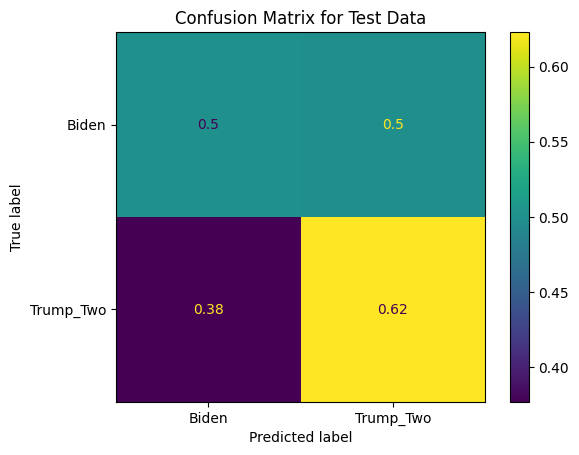

Test Set Balanced Accuracy: 0.5615956833545468


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

lr = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=5).fit(X_train, y_train)
predictions = lr.predict(X_test)
cm = confusion_matrix(y_test, predictions, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

In [ ]:
coef_df = pd.DataFrame(
    lr.coef_,
    columns=feature_names,
    index=lr.classes_
).T

# Positive values mean that feature increases the probability of that era
# Negative values mean it decreases the probability
print("Coefficients by Feature and Administration:")
display(coef_df)

for admin in lr.classes_:
    print(f"\n--- Top 5 Features predicting the {admin} Era ---")
    print(coef_df[admin].sort_values(ascending=False).head(5))

Coefficients by Feature and Administration:


,Biden,Trump_One,Trump_Two
product_Consumer Loan,-1.088685,1.763773,-0.675088
product_Credit Card or Prepaid Card,-0.109285,0.251656,-0.142371
product_Credit Reporting,-0.117839,-0.560736,0.678576
product_Debt collection,-0.379480,0.264445,0.115035
product_Debt or credit management,0.248569,-1.371106,1.122537
"product_Money Transfer, Virtual Currency, or Money Service",0.111744,-0.278325,0.166580
product_Mortgage,-0.133383,0.824390,-0.691007
product_Payday Loan,-0.154753,0.288075,-0.133323
product_Student loan,-0.345877,0.665594,-0.319718
product_Vehicle loan or lease,-0.107105,0.225828,-0.118723



--- Top 5 Features predicting the Biden Era ---
submitted_via_Phone                                             0.688335
company_response_to_consumer_Closed with non-monetary relief    0.573731
submitted_via_Web                                               0.463352
submitted_via_Referral                                          0.310151
product_Debt or credit management                               0.248569
Name: Biden, dtype: float64

--- Top 5 Features predicting the Trump_One Era ---
product_Consumer Loan      1.763773
product_Mortgage           0.824390
product_Student loan       0.665594
product_Payday Loan        0.288075
product_Debt collection    0.264445
Name: Trump_One, dtype: float64

--- Top 5 Features predicting the Trump_Two Era ---
submitted_via_Web                                               1.435259
product_Debt or credit management                               1.122537
company_response_to_consumer_Untimely response                  1.007378
product_Credit Report

In [ ]:
import numpy as np
import pandas as pd

intercept_df = pd.DataFrame(lr.intercept_, index=lr.classes_, columns=['Intercept'])
print(intercept_df)

odds_ratios = np.exp(lr.coef_)

or_df = pd.DataFrame(
    odds_ratios,
    columns=feature_names,
    index=lr.classes_
).T

# "Percent Change" version for easier reading
pct_df = (or_df - 1) * 100

print("--- Odds Ratios (Likelihood Multiplier) ---")
display(or_df.head(10))

for admin in lr.classes_:
    print(f"\nTop indicators for {admin}:")
    # Sort by the highest percentage increase
    top_indicators = pct_df[admin].sort_values(ascending=False).head(5)
    for feature, val in top_indicators.items():
        print(f" > {feature}: {val:.1f}% more likely")

--- Odds Ratios (Likelihood Multiplier) ---


,Biden,Trump_One,Trump_Two
product_Consumer Loan,0.336659,5.834408,0.509112
product_Credit Card or Prepaid Card,0.896475,1.286154,0.867299
product_Credit Reporting,0.888839,0.570789,1.971068
product_Debt collection,0.684217,1.302708,1.121913
product_Debt or credit management,1.282189,0.253826,3.072639
"product_Money Transfer, Virtual Currency, or Money Service",1.118227,0.757051,1.181259
product_Mortgage,0.875130,2.280489,0.501071
product_Payday Loan,0.856627,1.333858,0.875183
product_Student loan,0.707600,1.945647,0.726354
product_Vehicle loan or lease,0.898431,1.253360,0.888054



Top indicators for Biden:
 > submitted_via_Phone: 99.0% more likely
 > company_response_to_consumer_Closed with non-monetary relief: 77.5% more likely
 > submitted_via_Web: 58.9% more likely
 > submitted_via_Referral: 36.4% more likely
 > product_Debt or credit management: 28.2% more likely

Top indicators for Trump_One:
 > product_Consumer Loan: 483.4% more likely
 > product_Mortgage: 128.0% more likely
 > product_Student loan: 94.6% more likely
 > product_Payday Loan: 33.4% more likely
 > product_Debt collection: 30.3% more likely

Top indicators for Trump_Two:
 > submitted_via_Web: 320.1% more likely
 > product_Debt or credit management: 207.3% more likely
 > company_response_to_consumer_Untimely response: 173.8% more likely
 > product_Credit Reporting: 97.1% more likely
 > company_response_to_consumer_Closed with non-monetary relief: 47.4% more likely


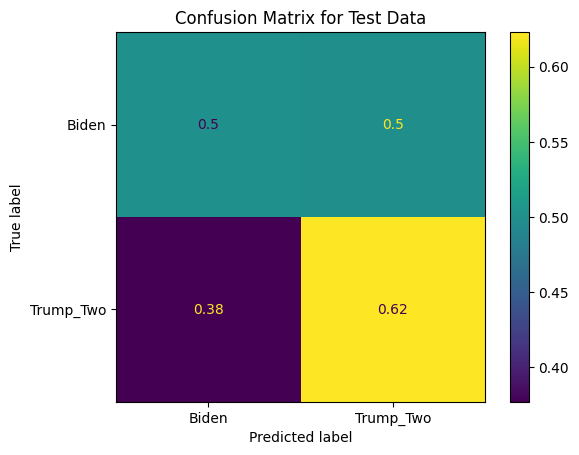

Test Set Balanced Accuracy: 0.5616379756150354


In [29]:
# https://scikit-learn.org/stable/modules/svm.html
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

svm_clf = svm.LinearSVC(class_weight='balanced').fit(X_train, y_train)
predictions = svm_clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Verify: Biden might be 0 and Trump_Two might be 1
print(f"Classes: {le.classes_}")

Classes: ['Biden' 'Trump_Two']


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

# Initialize the model
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',       # Standard for hidden layers
    solver='adam',           # Best for large datasets
    alpha=0.0001,            # L2 penalty to prevent overfitting
    batch_size=1024,         # Large batches for 11M rows
    learning_rate_init=0.005,
    max_iter=25,             # We use early stopping instead of many epochs
    early_stopping=True,     # CRITICAL: Stops training when validation score stalls
    validation_fraction=0.1, # Uses 10% of data to check for overfitting
    verbose=True,            # Shows progress so you know it hasn't crashed
    random_state=5
)

# Train the model
mlp.fit(X_train, y_train_encoded)

# Evaluate
predictions = mlp.predict(X_test)
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test_encoded, predictions))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test_encoded, predictions, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("Neural Network: Normalized Confusion Matrix")
plt.show()

Iteration 1, loss = 0.66830377
Validation score: 0.592982
Iteration 2, loss = 0.66690159
Validation score: 0.594571
Iteration 3, loss = 0.66609226
Validation score: 0.594072
Iteration 4, loss = 0.66540759
Validation score: 0.595534
Iteration 5, loss = 0.66485667
Validation score: 0.595795
Iteration 6, loss = 0.66432714
Validation score: 0.596240
Iteration 7, loss = 0.66387282
Validation score: 0.596611
Iteration 8, loss = 0.66349115
Validation score: 0.596990
Iteration 9, loss = 0.66315029
Validation score: 0.597618
Iteration 10, loss = 0.66281280
Validation score: 0.597828
Iteration 11, loss = 0.66255383
Validation score: 0.598237
Iteration 12, loss = 0.66234400
Validation score: 0.597731
Iteration 13, loss = 0.66212478
Validation score: 0.598894
Iteration 14, loss = 0.66194893
Validation score: 0.598167
Iteration 15, loss = 0.66178632
Validation score: 0.599203
Iteration 16, loss = 0.66164270
Validation score: 0.598713
Iteration 17, loss = 0.66147132
Validation score: 0.599388
Iterat

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


           Intercept
Biden      -0.487203
Trump_One   2.784734
Trump_Two  -2.297530


In [ ]:

# Would want more information on what features your using, and why you selected these features

# Why might it be so hard to predict admin? May be worth investigating given there are some features that are correlated with admin, e.g., consumer loans, submitted via web

# Would be interesting to compare performance vs. non-explainable models such as neural networks, etc.

The model is only performing about 5% better than random chance.

The data suggests that there is a lack of distinct patterns in the features.

Consumers tend to complain about the same products regardless of the administration. Credit reporting consists of 77% of all complaints. As a result, most complaint's product feature does not help the model distinguish between administrations.

Similarly, most complaints are submitted through the Web. Since the behavior of how people submit complaints does not change a lot when the administration changes, this feature does not have a lot of predictive power.

The ways companies respond appear to be standard industry practices that do not change based on who is in the White House.

As a result, the model does not perform much higher than random since the features do not capture any political or economic changes that define an administration.

To improve it might help to look at the Complaint Narrative feature to find specific policy-related language that changes between the administrations.